# Tarea 01: Aproximación de una función desconocida

Generamos datos con una función que **nosotros definimos y ustedes no conocen**. Su
trabajo es reconstruirla a partir de los datos.

No es un acertijo: es lo que hace el machine learning todos los días. El capítulo 02
plantea el aprendizaje como **aproximación de funciones**, y aquí van a hacer
exactamente eso, con la ventaja rara de que existe una respuesta correcta y un límite
teórico al que se puede llegar.

## Lo que hay

- `train.csv`: 800 observaciones con 12 variables (`x1` a `x12`) y la respuesta `y`.
- `test.csv`: 400 observaciones con las mismas 12 variables, **sin** `y`.

Entregan sus 400 predicciones y un bot las califica automáticamente.

## Cómo se califica

| Su MSE en el conjunto de prueba | Calificación |
|---|---|
| Igual o peor que una regresión lineal con las 12 variables crudas | **5.0** |
| Igual al modelo bien especificado (el error irreducible) | **10.0** |
| En medio | proporcional a la mejora |

**El 5 está garantizado si entregan algo que corre.** El código del baseline se lo damos
hecho más abajo; de ahí para arriba es mérito suyo.

Tienen **3 intentos** de calificación. Un comentario `/validar` revisa el formato y les
dice cuál es su MSE objetivo **sin gastar intento**, así que úsenlo antes del primero.

## Qué se evalúa además del MSE

El MSE es la mitad. La otra mitad es la **Parte 5: la bitácora**, donde documentan cada
hipótesis que probaron — incluidas las que fallaron. Un notebook con buen MSE y bitácora
vacía vale poco: significa que no entendieron por qué funcionó.

---

## Las reglas sobre la IA

**Sí pueden usar IA. De hecho quiero que la usen.** Pero de una forma específica.

La IA no puede ver sus datos. Puede explicarles teoría, listarles técnicas o decirles qué
función de `matplotlib` usar. Lo que **no** puede hacer es mirar una gráfica de residuales
y decirles qué término falta, porque eso solo lo revela correr el código con *sus* datos, y
cada quien tiene datos distintos.

Así que la IA es su tutor, no su chofer. Para que sea tutor, péguenle esto al inicio de
cada conversación:

> Eres mi tutor de regresión, no mi resolvedor. Reglas: (1) no escribes código que yo
> pueda copiar; si te pido código, me devuelves el nombre de la función y su docstring.
> (2) No me das la respuesta: me preguntas qué espero ver y por qué. (3) Cuando me
> equivoque, no me corriges: me sugieres qué gráfica revelaría mi error. (4) Máximo
> tres oraciones por respuesta.

Y una regla para ustedes: **si la IA les da código y no pueden explicar qué hace línea
por línea, bórrenlo y escríbanlo ustedes.** Se nota en la bitácora, y se nota más en el
examen.

---
## Parte 0. Su variante

Cada quien tiene **datos distintos**: las 12 variables juegan papeles diferentes según
la persona. Copiar las predicciones de alguien más da un MSE malísimo. Comparar
*métodos* entre ustedes, en cambio, es buena idea y se los recomiendo.

Su carpeta de datos se identifica con su **clave única del ITAM**.

In [1]:
import hashlib
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LassoCV, LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams["figure.dpi"] = 110
SEMILLA = 42

In [2]:
# TODO: pongan su clave única del ITAM (con o sin ceros a la izquierda, da lo mismo)
CLAVE_UNICA = "214245"

# De la clave sale el nombre de su carpeta. No lo cambien a mano.
_clave = "".join(c for c in CLAVE_UNICA if c.isdigit()).zfill(9)
CARPETA = "v" + hashlib.sha256(_clave.encode()).hexdigest()[:8]

# Funciona corriendo el notebook desde `tareas/` o desde la raíz del repo
RAIZ = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "tareas/tarea_01_datos").exists())
MIS_DATOS = RAIZ / "tareas/tarea_01_datos" / CARPETA

assert CLAVE_UNICA, "Escriban su clave única en CLAVE_UNICA."
assert MIS_DATOS.exists(), (
    f"No existe la carpeta {CARPETA}. Revisen su clave única: si está mal escrita, "
    f"el nombre de la carpeta sale distinto y no van a encontrar sus datos."
)

train = pd.read_csv(MIS_DATOS / "train.csv")
test = pd.read_csv(MIS_DATOS / "test.csv")

VARIABLES = [f"x{i}" for i in range(1, 13)]
print(f"Su variante: {CARPETA}")
print(f"train: {train.shape}   test: {test.shape}")
train.head()

Su variante: vca1fec98
train: (800, 13)   test: (400, 12)


,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,x12,y
0,-1.836324,0.466731,-0.385594,0.187457,0.264815,91.179271,-0.423739,0.995881,2.852695,0.155165,3.365516,3.242985,8.809402
1,1.913288,0.144765,-0.281999,0.252806,-0.396607,4.561032,-1.740750,-2.071853,2.379640,-1.011022,1.611325,0.544112,25.081143
2,-0.254875,0.423503,-0.910639,-0.418849,0.195882,21.502290,0.503512,-0.088578,0.302156,1.121312,3.246693,1.311269,10.426509
3,1.017343,0.328149,0.545270,-0.396460,-0.182838,48.473573,0.109023,0.219696,2.073591,-1.809688,0.680854,4.685270,5.140764
4,1.613129,2.916600,0.670921,-0.324329,-0.007261,7.317397,-1.278021,-1.665070,0.090134,-0.475989,1.284861,0.459252,31.384558


In [12]:
# TODO: primer vistazo. ¿Qué rangos tienen las variables? ¿Hay faltantes?
display(train.describe().T)
display(train.isna().sum())
display(train.info())

,count,mean,std,min,25%,50%,75%,max
x1,800.0,0.032208,1.165578,-1.998676,-1.015354,0.066551,1.049276,1.997882
x2,800.0,1.731902,2.323425,0.068482,0.495552,1.008584,2.111984,28.564349
x3,800.0,-0.002919,1.032073,-4.056300,-0.684051,0.003655,0.668989,3.180068
x4,800.0,0.006969,0.288952,-0.499223,-0.240581,-0.004167,0.262954,0.499448
x5,800.0,-0.000688,0.285109,-0.499853,-0.254395,0.007687,0.232466,0.495974
x6,800.0,50.970435,28.649875,0.010833,26.500688,51.995442,75.290937,99.932808
x7,800.0,0.015793,1.153846,-1.997401,-0.948506,-0.025427,1.020614,1.999167
x8,800.0,0.042094,0.954227,-2.685470,-0.599923,0.055133,0.676215,3.406516
x9,800.0,-0.050520,1.711434,-2.996114,-1.515034,-0.048910,1.374177,2.991040
x10,800.0,-0.022713,1.705927,-2.999399,-1.498492,-0.038969,1.376076,2.980858


x1     0
x2     0
x3     0
x4     0
x5     0
x6     0
x7     0
x8     0
x9     0
x10    0
x11    0
x12    0
y      0
dtype: int64

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x1      800 non-null    float64
 1   x2      800 non-null    float64
 2   x3      800 non-null    float64
 3   x4      800 non-null    float64
 4   x5      800 non-null    float64
 5   x6      800 non-null    float64
 6   x7      800 non-null    float64
 7   x8      800 non-null    float64
 8   x9      800 non-null    float64
 9   x10     800 non-null    float64
 10  x11     800 non-null    float64
 11  x12     800 non-null    float64
 12  y       800 non-null    float64
dtypes: float64(13)
memory usage: 81.4 KB


None

### 0.1 El baseline que hay que ganar

Este es el modelo de referencia: una regresión lineal con las 12 variables **tal como
vienen**, sin transformar nada. Su MSE sobre el conjunto de prueba es, por definición, la
calificación **5.0**.

Se lo damos corrido para que arranquen sabiendo exactamente qué hay que superar.

In [6]:
X_train, X_val, y_train, y_val = train_test_split(
    train[VARIABLES], train["y"], test_size=0.25, random_state=SEMILLA
)

baseline = LinearRegression().fit(X_train, y_train)
mse_baseline = mean_squared_error(y_val, baseline.predict(X_val))

print(f"MSE del baseline en validación: {mse_baseline:.2f}")
print(f"R² del baseline en validación : {baseline.score(X_val, y_val):.3f}")
print(f"\nDesviación estándar de y: {train['y'].std():.2f}")

MSE del baseline en validación: 101.98
R² del baseline en validación : 0.507

Desviación estándar de y: 14.73


### 0.2 Cómo medir su progreso sin gastar intentos

Solo tienen 3 calificaciones, y necesitan medirse muchas más veces que eso. La solución
es la de siempre: **partir `train` en entrenamiento y validación**, ajustar en una parte
y medir en la otra. Eso ya lo hicimos en la celda anterior.

Dos advertencias importantes:

- Su MSE de validación **no** va a coincidir exactamente con el oficial. El oficial se
  mide sobre `test.csv`, que son otras 400 observaciones. Su número es una *estimación*
  del oficial, con su propia incertidumbre.
- Si eligen entre muchos modelos usando el mismo conjunto de validación, van a
  sobreajustar la validación. Para decisiones finas, usen validación cruzada
  (`cross_val_score`) en lugar de una sola partición.

**Nunca** ajusten nada usando `test.csv`: no tiene `y`, así que ni podrían — y ese es
justo el punto.

---
## Parte 1. Exploración

Antes de modelar, mírenlos. El objetivo de esta parte **no** es encontrar la respuesta,
es formarse sospechas que después van a confirmar o descartar.

Tres cosas que vale la pena graficar:

1. La distribución de cada variable por separado.
2. `y` contra cada variable, una gráfica por variable.
3. La matriz de correlación.

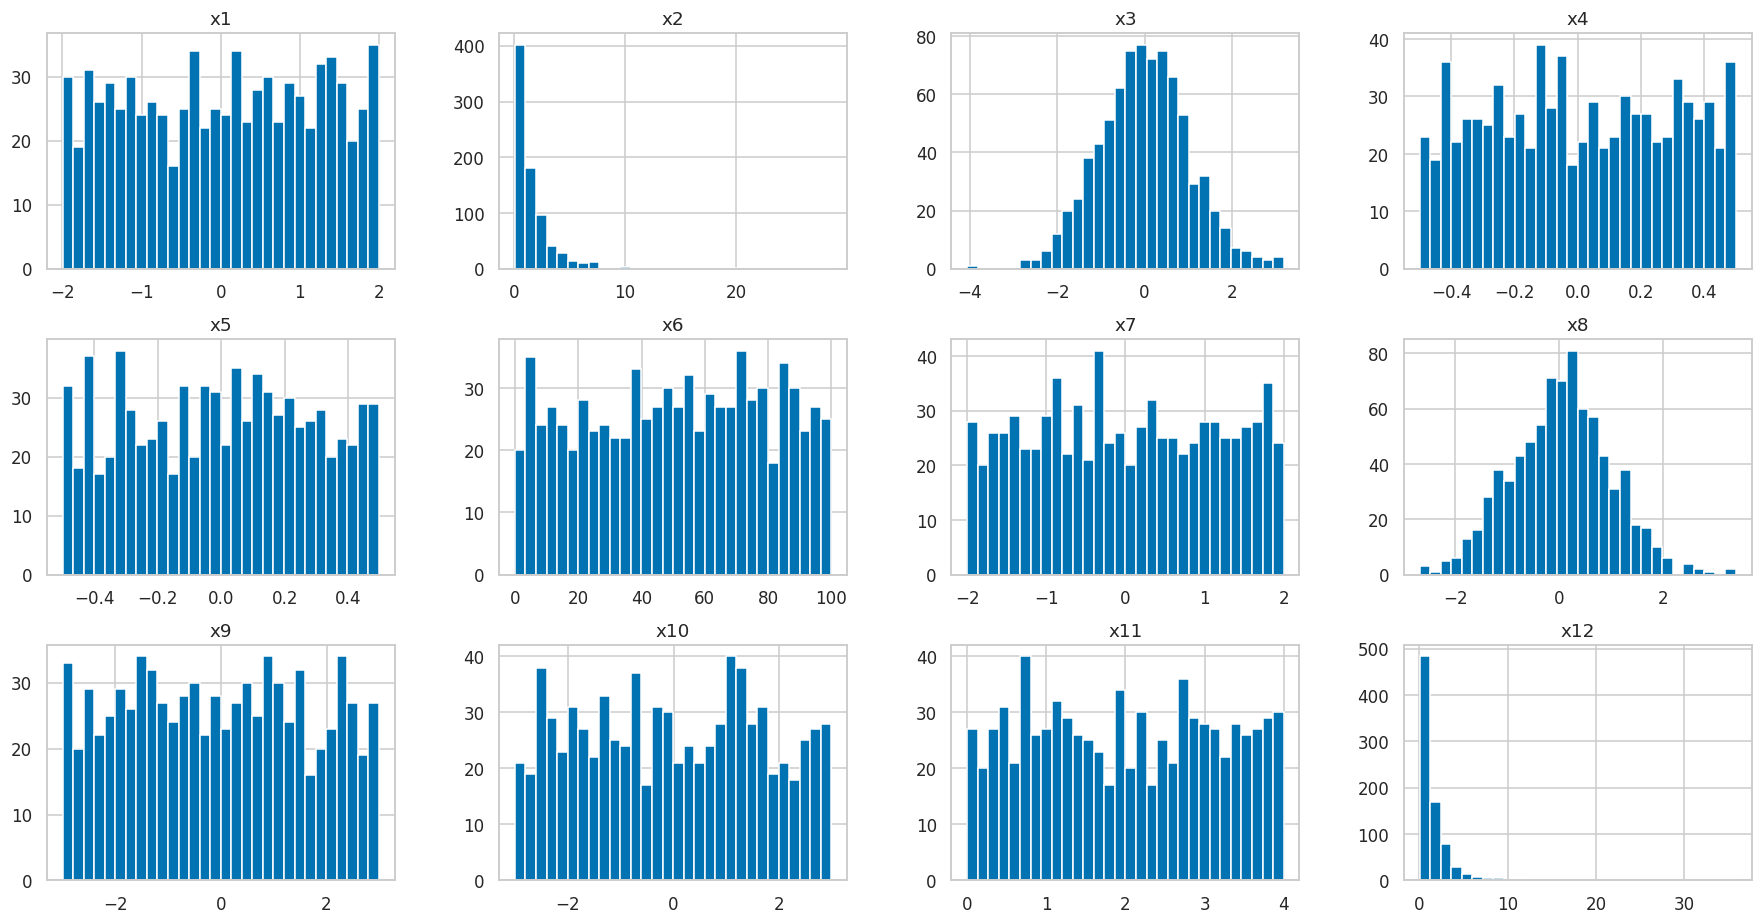

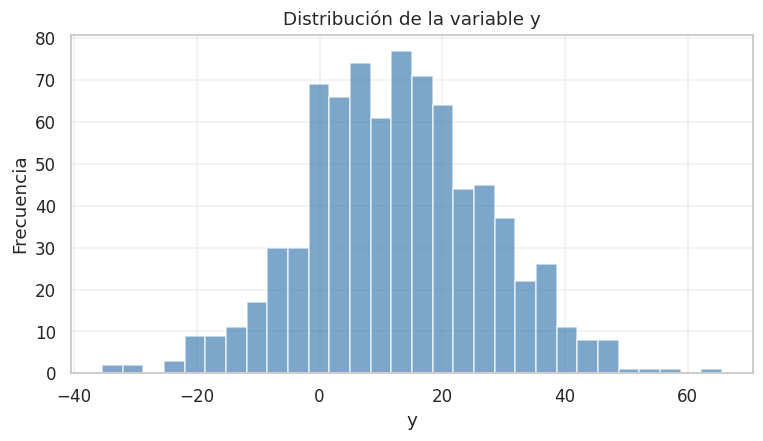

In [34]:
# TODO: distribución de cada una de las 12 variables.
# Pista de método: `train[VARIABLES].hist(...)` hace las 12 de un golpe.
train[VARIABLES].hist(figsize=(20, 10), bins=30, layout=(3, 4))
plt.show()

# Distribución de la variable objetivo
plt.figure(figsize=(8, 4))
plt.hist(train['y'], bins=30, color='steelblue', alpha=0.7)
plt.title('Distribución de la variable y')
plt.xlabel('y')
plt.ylabel('Frecuencia')
plt.grid(True, alpha=0.3)
plt.show()

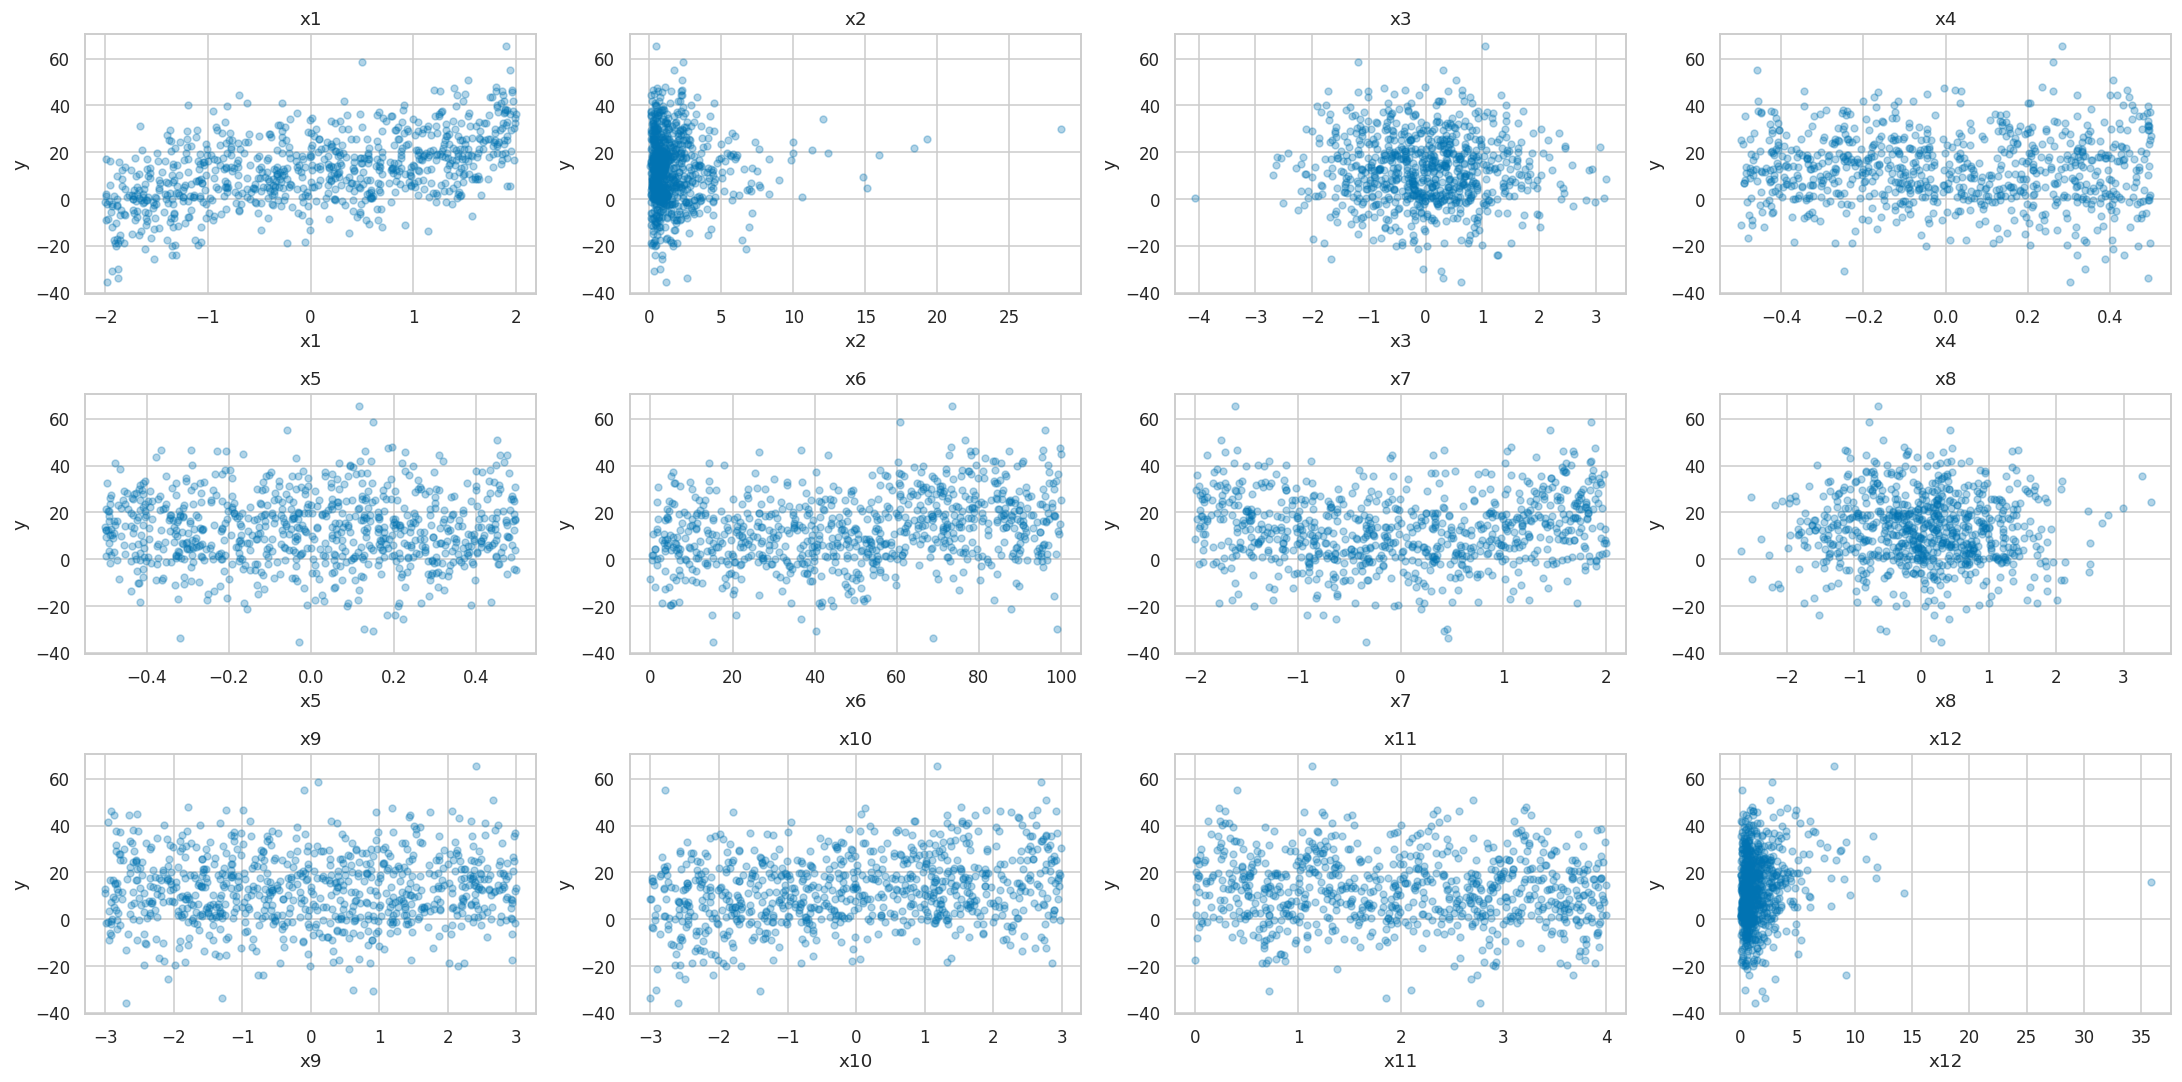

In [38]:
# TODO: `y` contra cada variable. Una rejilla de 12 paneles.
# Usen puntos con transparencia (`alpha`): con 800 observaciones se traslapan.
fig, axes = plt.subplots(3, 4, figsize=(20, 10))
axes = axes.flatten()

for i, var in enumerate(VARIABLES):
    train.plot.scatter(x=var, y="y", alpha=0.3, ax=axes[i])
    axes[i].set_title(var)

plt.tight_layout()
plt.show()




,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,x12,y
x1,1.000000,0.036897,-0.043609,-0.078262,-0.050474,0.013265,0.000163,-0.084876,-0.027158,0.003192,0.003093,-0.009837,0.531844
x2,0.036897,1.000000,0.023031,-0.008324,0.020254,0.040970,-0.003039,0.020863,0.021464,-0.044433,-0.013104,-0.036267,0.022735
x3,-0.043609,0.023031,1.000000,0.022492,0.011923,0.004752,-0.011582,-0.014640,-0.001864,-0.037822,-0.062576,0.003600,-0.026589
x4,-0.078262,-0.008324,0.022492,1.000000,0.022665,0.070158,-0.037937,-0.039030,0.008186,0.002755,0.088614,-0.019651,-0.037617
x5,-0.050474,0.020254,0.011923,0.022665,1.000000,-0.002034,0.048215,0.010578,-0.039530,0.006443,-0.023100,0.005682,-0.001875
x6,0.013265,0.040970,0.004752,0.070158,-0.002034,1.000000,0.060180,0.024362,0.040567,0.007747,-0.026079,0.035205,0.285692
x7,0.000163,-0.003039,-0.011582,-0.037937,0.048215,0.060180,1.000000,-0.025502,-0.051129,0.037071,0.039830,-0.039185,0.057536
x8,-0.084876,0.020863,-0.014640,-0.039030,0.010578,0.024362,-0.025502,1.000000,0.027260,0.033798,-0.025458,0.024031,-0.030007
x9,-0.027158,0.021464,-0.001864,0.008186,-0.039530,0.040567,-0.051129,0.027260,1.000000,0.022256,-0.025064,0.055748,0.040016
x10,0.003192,-0.044433,-0.037822,0.002755,0.006443,0.007747,0.037071,0.033798,0.022256,1.000000,-0.014761,0.007074,0.275775


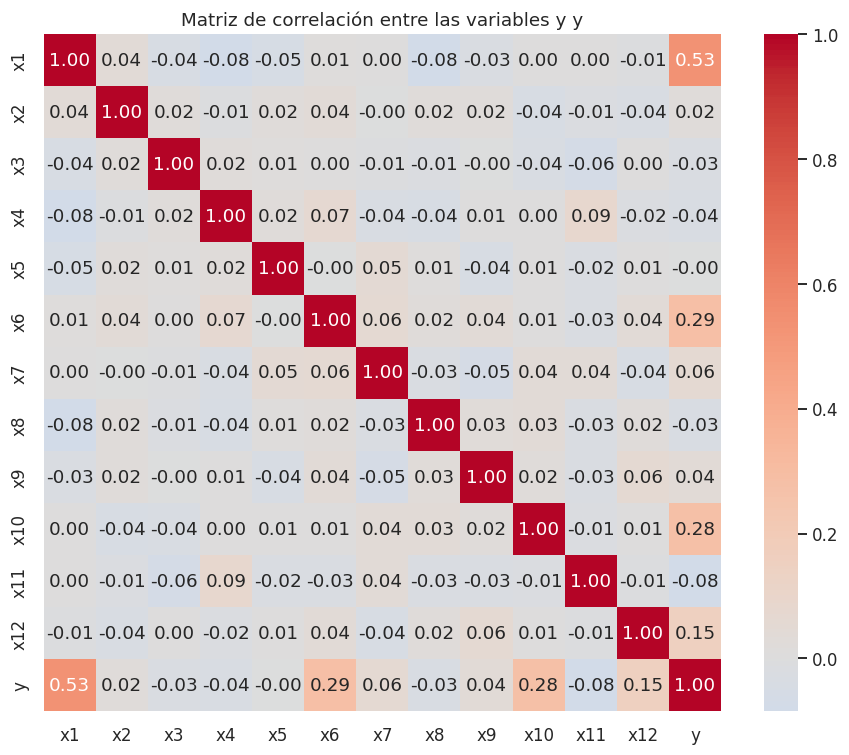

In [40]:
# TODO: matriz de correlación entre las 12 variables y `y`.
display(train[VARIABLES + ['y']].corr())

corr = train[VARIABLES + ['y']].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Matriz de correlación entre las variables y y")
plt.show()

### 1.1 Registren sus sospechas ahora

Llenen esta tabla **antes** de seguir. Va a ser incómoda de llenar y eso es intencional:
la parte que enseña es volver a leerla al final y ver en qué se equivocaron.

| Variable | ¿Qué sospecho? | ¿En qué gráfica lo vi? | ¿Qué tan seguro estoy? |
|---|---|---|---|
| `x1` | Relación lineal positiva con `y` | Dispersión x1-y + heatmap (corr = 0.53, la más alta) | Muy seguro |
| `x2` | relación no lineal, con distribución muy sesgada a la derecha. una transformación log(x2) puede mostrar mas| histograma tiene forma de “L” (muchos valores cerca de 0, pocos grandes). | Seguro |
| `x3` | sin relación aparente, aunque tenga distribucion en campana normal, como y | Heatmap de correlacion   ≈ 0 y dispersion sin patron| Seguro |
| `x4` | Distribucion Uniforme, sin relacion con y| Histograma plano, dispersion sin tendencia, correlacion  ≈ 0| Segurp |
| `x5` | Uniforme, rango pequeño, sin relación con y | Histograma plano + dispersión sin tendencia + heatmap (corr ≈ 0.00) |Seguro| 
| `x6` | Relación positiva moderada con y| Dispersión x6-y (nube ascendente con dispersión) + heatmap (corr = 0.29)  |Bastante seguro |
| `x7` | Uniforme, sin relación clara con y| Histograma plano + dispersión sin patrón + heatmap (corr = 0.06) | Tal vez tenga una relación débil|
| `x8` | Distribución casi normal con ligera cola derecha; sin relación lineal con y| Histograma asimétrico + dispersión sin tendencia + heatmap (corr = -0.03) |  Seguro |
| `x9` | Uniforme, sin relación con y | Histograma plano + dispersión sin patrón + heatmap (corr = 0.04) |  Seguro |
| `x10` | Relación positiva moderada con y, similar a x6| Dispersión x10-y (tendencia ascendente con ruido) + heatmap (corr = 0.28) | Bastante seguro|
| `x11` | Uniforme (0 a 4), sin relación con y| Histograma plano + dispersión sin patrón visible + heatmap (corr = -0.08) | Poco seguro por la pequena correlación con y, y uede estar corr con x4 |
| `x12` | Muy sesgada a la derecha (como x2), mayoría cerca de 0, relación débil-positiva con y | Histograma en “L” + dispersión x12-y (nube pegada a 0) + heatmap (corr con y = 0.15| Medianamente seguro 

---
## Parte 2. La escalera de residuales

Este es el método central de la tarea, y el que quiero que se lleven de por vida.

Un **residual** es lo que su modelo no logró explicar: `residual = y - ŷ`. Si su modelo
capturó todo lo que había, los residuales deben ser **ruido**: sin forma, sin patrón, sin
estructura. Si al graficar los residuales contra una variable se ve una *forma*, esa
forma es un pedazo de la función que les falta — y la forma les dice qué término agregar.

El ciclo es siempre el mismo:

1. Ajustan el modelo que tienen.
2. Grafican los residuales contra **cada** variable.
3. Si alguna gráfica tiene forma, agregan un término que capture esa forma.
4. Vuelven al paso 1.

Paran cuando ya ninguna gráfica tiene forma, o cuando el MSE deja de bajar.

### ¿Y qué término agrego?

Eso es exactamente lo que tienen que descubrir, y es el trabajo de la tarea.

Lo que sí les conviene es pedirle a su IA el **catálogo**: "¿qué transformaciones existen
para linealizar una relación no lineal?", "¿cómo se modela un efecto que cambia de golpe
a partir de cierto valor?". Eso es conocimiento general y la IA lo tiene completo.

Cuál de esas transformaciones aplica, a cuál de sus doce variables y con qué parámetro,
no se lo puede decir nadie: solo su gráfica. Ahí es donde se aprende.

In [44]:
def ajusta(columnas_extra=None):
    """Ajusta una lineal con las 12 crudas más las columnas derivadas que le pasen.

    `columnas_extra` es un dict {nombre: función que recibe un DataFrame y devuelve
    una Serie}. Así el mismo término se construye igual en train, validación y test,
    que es donde se equivoca todo el mundo.

    Devuelve (modelo, mse_validacion, residuales_de_validacion, constructor).
    """
    columnas_extra = columnas_extra or {}

    def construye(df):
        salida = df[VARIABLES].copy()
        for nombre, f in columnas_extra.items():
            salida[nombre] = f(df)
        return salida

    modelo = LinearRegression().fit(construye(X_train), y_train)
    pred_val = modelo.predict(construye(X_val))
    mse = mean_squared_error(y_val, pred_val)
    return modelo, mse, y_val - pred_val, construye


modelo, mse, residuales, _ = ajusta()
print(f"Modelo con las 12 crudas -> MSE de validación {mse:.2f}")

Modelo con las 12 crudas -> MSE de validación 101.98


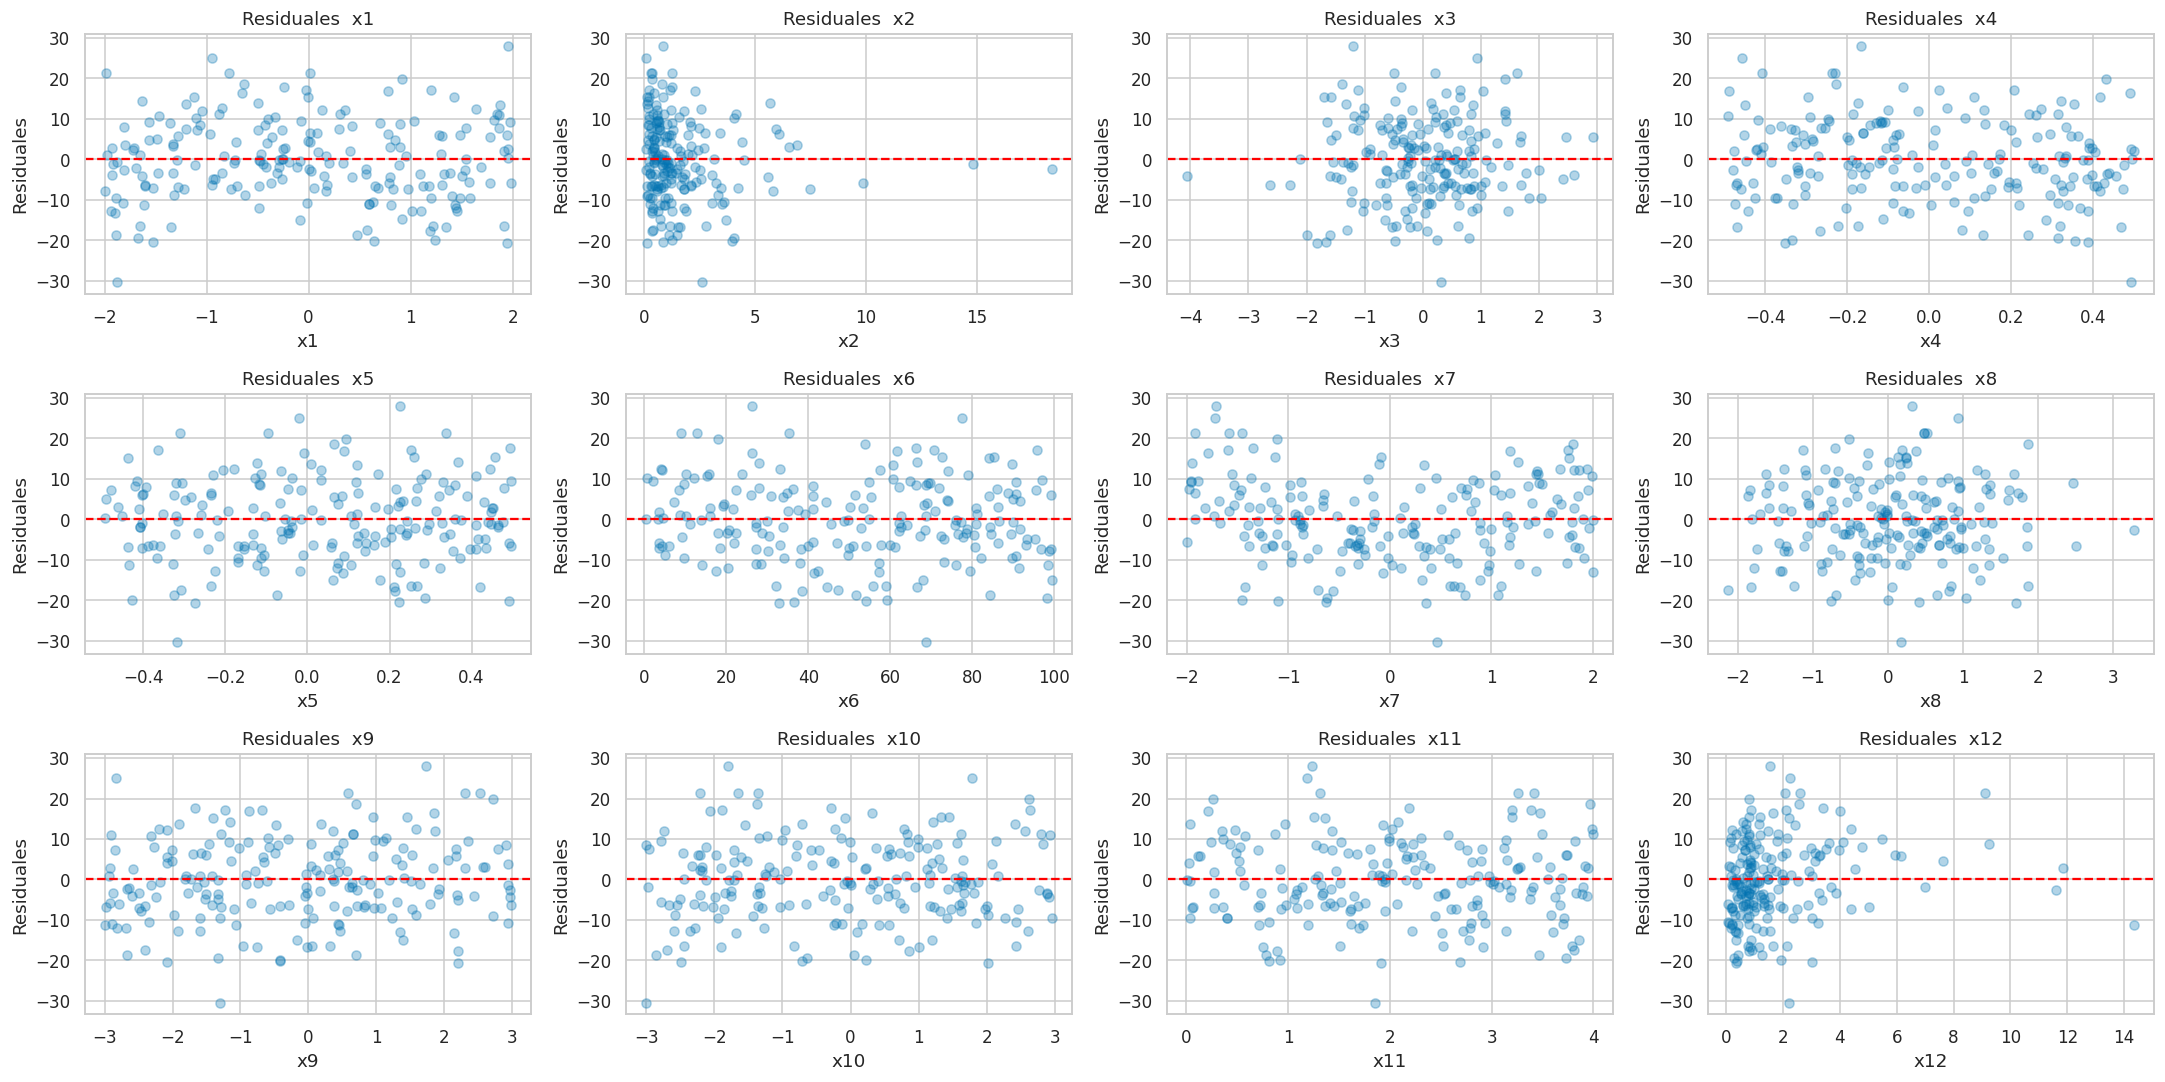

In [47]:
# TODO: grafiquen los residuales contra cada una de las 12 variables.
# Una rejilla de 12 paneles, y en cada uno una línea horizontal en 0 como referencia.
#
# Lo que buscan es FORMA, no dispersión. Una nube gruesa sin patrón está bien;
# una nube que sube, baja, ondula o salta es un término que les falta.

fig, axes = plt.subplots(3, 4, figsize=(20, 10))
axes = axes.flatten()   

for i, var in enumerate(VARIABLES):
    axes[i].scatter(X_val[var], residuales, alpha=0.3)
    axes[i].axhline(0, color='red', linestyle='--')
    axes[i].set_title(f'Residuales  {var}')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Residuales')

plt.tight_layout()
plt.show()

In [89]:
# TODO: agreguen su primer término y vuelvan a medir.
#
# Así se le pasa una columna derivada a `ajusta`. El término del ejemplo es deliberadamente
# absurdo y NO sirve para nada: solo ilustra la sintaxis del diccionario y del lambda.
#
# modelo, mse, residuales, _ = ajusta({"disparate": lambda d: d["x1"] + d["x2"]})
# print(f"MSE: {mse:.2f}")
#
# Si el MSE bajó mucho, iban bien. Si no se movió, ese término no era. Anoten las dos
# cosas en la bitácora: los intentos fallidos también cuentan.
modelo_x1_sq, mse_x1, res_x1, _ = ajusta({"x1_sq": lambda d: d["x1"]**2})
print(f"x1²        -> MSE: {mse_x1:.2f}  (baseline: {mse:.2f})")

modelo_x2_sq, mse_x2, res_x2, _ = ajusta({"x2_sq": lambda d: d["x2"]**2})
print(f"x2²        -> MSE: {mse_x2:.2f}  (baseline: {mse:.2f})")

modelo_log_x2, mse_log_x2, res_log_x2, _ = ajusta({"log_x2": lambda d: np.log(d["x2"] + 1)}) # # log(1 + x2) evita problemas con ceros
print(f"log(1+x2)   -> MSE: {mse_log_x2:.2f}  (baseline: {mse:.2f})")

modelo_log_x12, mse_log_x12, res_log_x12, _ = ajusta({"log_x12": lambda d: np.log(d["x12"] + 1)}) # # log(1 + x12)
print(f"log(1+x12)  -> MSE: {mse_log_x12:.2f}  (baseline: {mse:.2f})")

modelo_log_x12_2, mse_log_x12_2, res_log_x12_2, _ = ajusta({"log_x12": lambda d: np.log(d["x12"])}) # # log(x12)
print(f"log(x12)    -> MSE: {mse_log_x12_2:.2f}  (baseline: {mse:.2f})")

modelo_sqrt_x12, mse_sqrt_x12, res_sqrt_x12, _ = ajusta({"sqrt_x12": lambda d: np.sqrt(d["x12"])}) # # sqrt(x12)
print(f"sqrt(x12)   -> MSE: {mse_sqrt_x12:.2f}  (baseline: {mse:.2f})")

modelo_x7_sq, mse_x7_sq, res_x7_sq, _ = ajusta({"x7_sq": lambda d: d["x7"]**2})
print(f"x7²        -> MSE: {mse_x7_sq:.2f}  (baseline: {mse:.2f})") 

modelo_x5_sq, mse_x5_sq, res_x5_sq, _ = ajusta({"x5_sq": lambda d: d["x5"]**2})
print(f"x5²        -> MSE: {mse_x5_sq:.2f}  (baseline: {mse:.2f})")

modelo_x6_sq, mse_x6_sq, res_x6_sq, _ = ajusta({"x6_sq": lambda d: d["x6"]**2})
print(f"x6²        -> MSE: {mse_x6_sq:.2f}  (baseline: {mse:.2f})")


x1²        -> MSE: 102.60  (baseline: 101.98)
x2²        -> MSE: 101.91  (baseline: 101.98)
log(1+x2)   -> MSE: 102.80  (baseline: 101.98)
log(1+x12)  -> MSE: 98.46  (baseline: 101.98)
log(x12)    -> MSE: 98.91  (baseline: 101.98)
sqrt(x12)   -> MSE: 98.44  (baseline: 101.98)
x7²        -> MSE: 92.47  (baseline: 101.98)
x5²        -> MSE: 102.50  (baseline: 101.98)
x6²        -> MSE: 101.23  (baseline: 101.98)


In [111]:
# TODO: repitan el ciclo. Agreguen términos de uno en uno, graficando los residuales
# cada vez, hasta que ninguna gráfica tenga forma.
#
# Vayan guardando el MSE de cada paso: la bitácora de la Parte 5 lo pide.
modelo_v2, mse_v2, residuales_v2, construye_v2 = ajusta({
    "log(1+x12)": lambda d: np.log(d["x12"] + 1),
    "x7²": lambda d: d["x7"]**2
})
print(f"x7² + log(1+x12)  -> MSE: {mse_v2:.2f}  (baseline: {mse:.2f})")

x7² + log(1+x12)  -> MSE: 89.44  (baseline: 101.98)


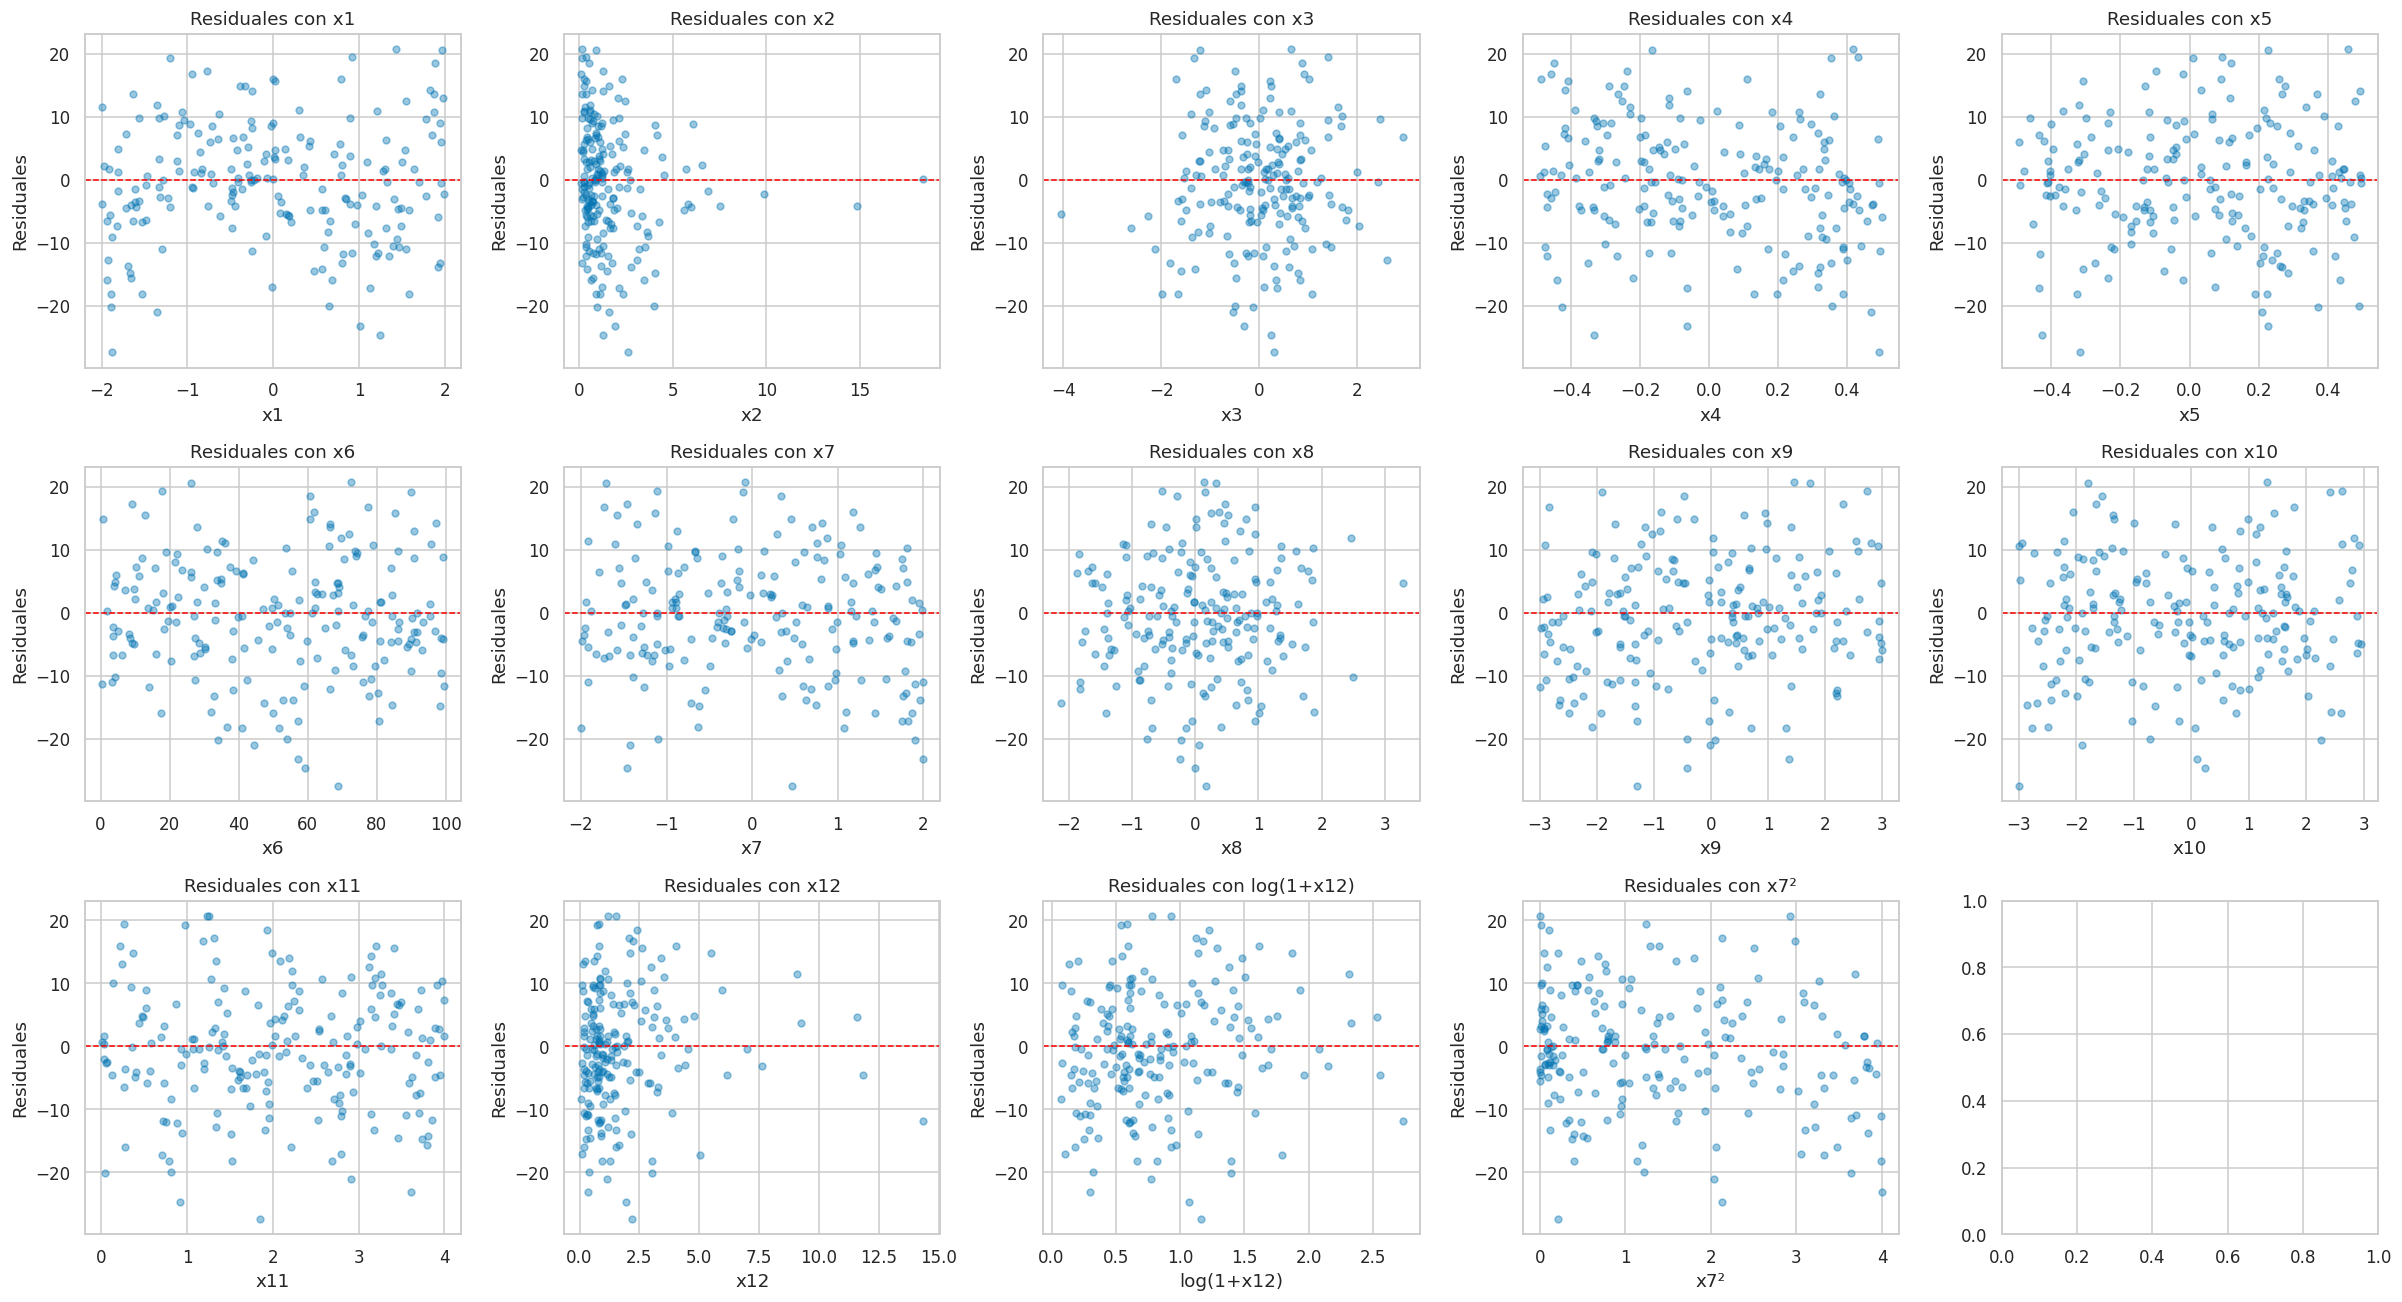

In [118]:
# Gráfico de residuales del modelo con x7² + log(1+x12)
X_val_v2 = construye_v2(X_val)

fig, axes = plt.subplots(3, 5, figsize=(22, 12))
axes = axes.flatten()

for i, col in enumerate(X_val_v2.columns):
    axes[i].scatter(X_val_v2[col], residuales_v2, alpha=0.4, s=20)
    axes[i].axhline(0, color='red', linestyle='--', linewidth=1)
    axes[i].set_title(f"Residuales con {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Residuales")

plt.tight_layout()
plt.show()


In [136]:
def ajusta_filtrado(columnas_extra=None, quitar=None):
    """
    Ajusta una regresión lineal con las 12 variables crudas más las columnas derivadas que se pasen.
    Permite excluir manualmente algunas variables.

    columnas_extra: dict {nombre: función que recibe un DataFrame y devuelve una Serie}
    quitar: lista de nombres de columnas a excluir del modelo

    Devuelve (modelo, mse_validacion, residuales_de_validacion, constructor, variables_usadas)
    """
    columnas_extra = columnas_extra or {}
    quitar = quitar or []

    # Definir las variables base menos las que se quieren quitar
    usadas = [v for v in VARIABLES if v not in quitar]

    def construye(df):
        salida = df[usadas].copy()
        for nombre, f in columnas_extra.items():
            salida[nombre] = f(df)
        return salida

    modelo = LinearRegression().fit(construye(X_train), y_train)
    pred_val = modelo.predict(construye(X_val))
    mse = mean_squared_error(y_val, pred_val)
    return modelo, mse, y_val - pred_val, construye, usadas

modelo_v2_2, mse_v2_2, residuales_v2_2, construye_v2_2, usadas_v2_2 = ajusta_filtrado(
    columnas_extra={
        "log(1+x12)": lambda d: np.log(d["x12"] + 1),
        "x7²": lambda d: d["x7"]**2
    },
    quitar=['x3', 'x4', 'x5', 'x7', 'x9', 'x11'])
print(f"Modelo usa: {construye_v2_2(X_val).columns.tolist()} -> MSE {mse_v2_2:.2f}  (baseline: {mse:.2f})  (modelo_v2: {mse_v2:.2f} )")
print(f"R² del modelo en validación : {modelo_v2_2.score(construye_v2_2(X_val), y_val):.3f}")

Modelo usa: ['x1', 'x2', 'x6', 'x8', 'x10', 'x12', 'log(1+x12)', 'x7²'] -> MSE 87.05  (baseline: 101.98)  (modelo_v2: 89.44 )
R² del modelo en validación : 0.580


In [154]:
modelo_v2_2, mse_v2_2, residuales_v2_2, construye_v2_2, usadas_v2_2 = ajusta_filtrado(
    columnas_extra={
        "log(1+x12)": lambda d: np.log(d["x12"] + 1),
        "x7²": lambda d: d["x7"]**2
    },
    quitar=['x2', 'x3', 'x4', 'x7', 'x8', 'x9', 'x12'])
print(f"Modelo usa: {construye_v2_2(X_val).columns.tolist()} -> MSE {mse_v2_2:.2f}  (baseline: {mse:.2f})  (modelo_v2: {mse_v2:.2f} )")

print(f"R² del modelo en validación : {modelo_v2_2.score(construye_v2_2(X_val), y_val):.3f}")

Modelo usa: ['x1', 'x5', 'x6', 'x10', 'x11', 'log(1+x12)', 'x7²'] -> MSE 84.42  (baseline: 101.98)  (modelo_v2: 89.44 )
R² del modelo en validación : 0.592


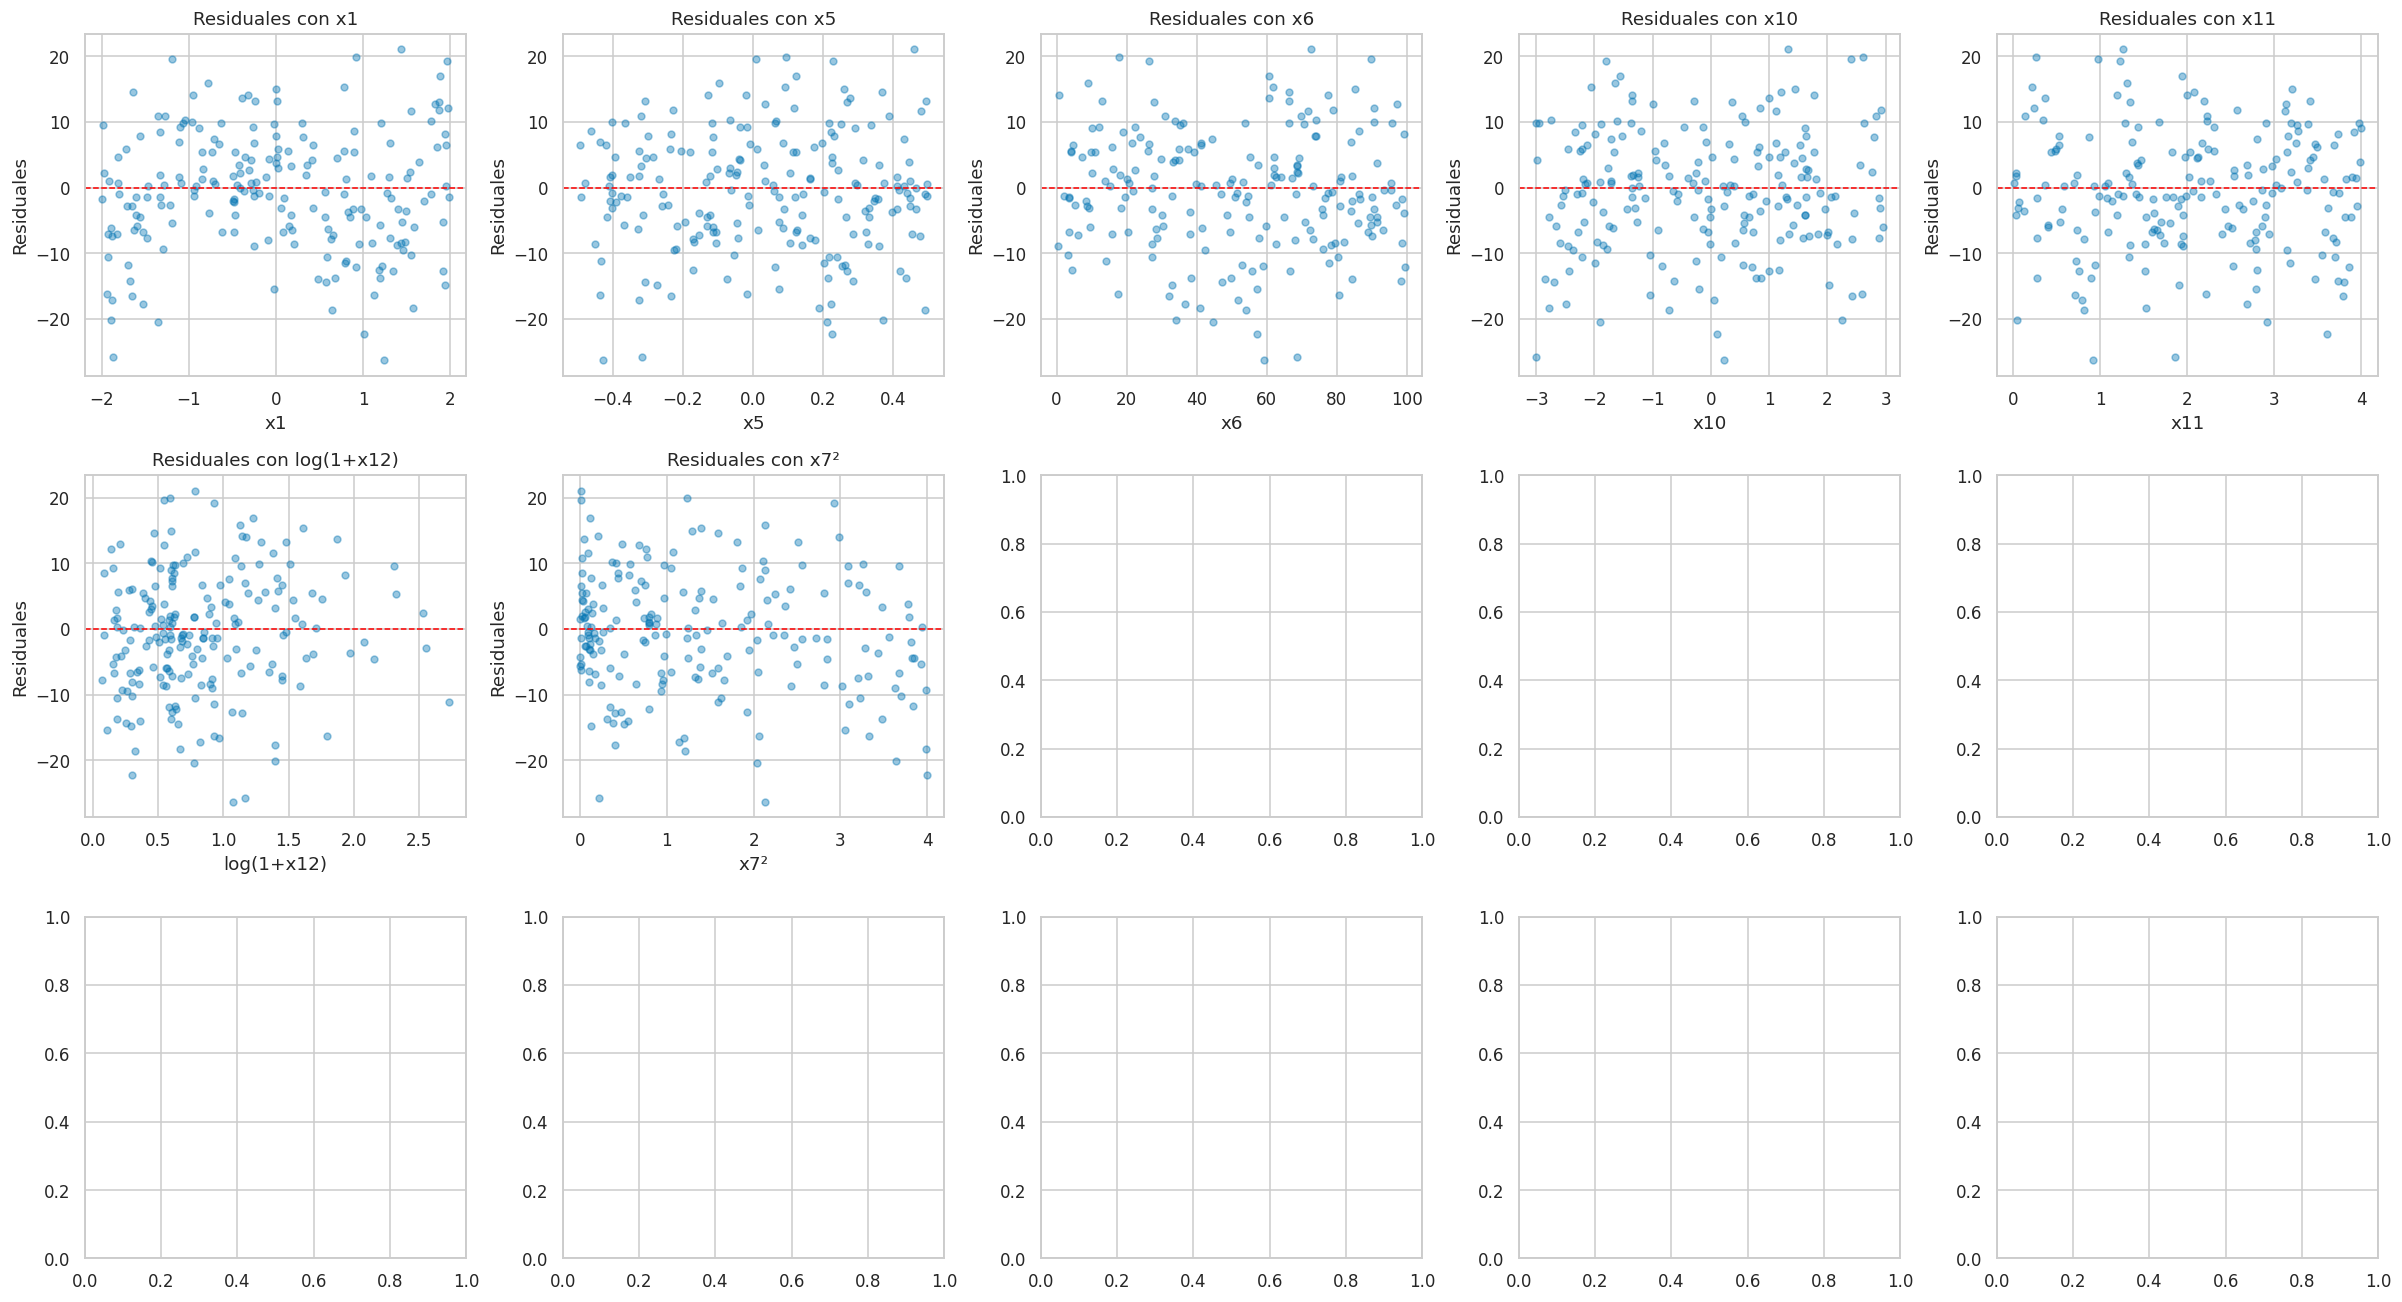

In [155]:
#grafica residuales del modelo v2_2
X_val_v2_2 = construye_v2_2(X_val)
fig, axes = plt.subplots(3, 5, figsize=(22, 12))
axes = axes.flatten()

for i, col in enumerate(X_val_v2_2.columns):
    axes[i].scatter(X_val_v2_2[col], residuales_v2_2, alpha=0.4, s=20)
    axes[i].axhline(0, color='red', linestyle='--', linewidth=1)
    axes[i].set_title(f"Residuales con {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Residuales")

plt.tight_layout()
plt.show()

---
## Parte 3. Lo que las gráficas de una variable no pueden ver

Cuando terminen la Parte 2 van a tener un modelo decente y, probablemente, ninguna
gráfica de residuales con forma evidente. Eso **no** significa que ya acabaron.

Hay efectos que son invisibles para cualquier gráfica de una sola variable: pueden tener
correlación cero con `y`, scatter plano y residual sin estructura, y aun así ser de los
efectos más grandes del modelo. Ninguna herramienta de la Parte 2 los encuentra.

Su trabajo aquí es averiguar **qué clase de efectos son, cómo se detectan, y si sus datos
tienen alguno**. Su IA les puede explicar la teoría si le hacen la pregunta correcta; sus
datos son los únicos que pueden contestar si aplica.

Una pista de método y ninguna de contenido: si mirar una variable a la vez no basta,
prueben mirando dos a la vez.

In [158]:
# TODO: exploren aquí.
#
# Son 66 pares de variables y no tienen que revisarlos a ciegas: usen lo que ya
# aprendieron en la Parte 2 para decidir por dónde empezar.
# 1. Barrido de todos los pares: correlación del residual con el producto
import itertools

candidatos = []
for xi, xj in itertools.combinations(VARIABLES, 2):
    producto = X_val[xi] * X_val[xj]
    corr = np.corrcoef(residuales_v2, producto)[0, 1]
    candidatos.append((abs(corr), xi, xj, corr))

candidatos.sort(reverse=True)
for _, xi, xj, corr in candidatos[:10]:
    print(f"{xi} x {xj}: corr con residual = {corr:.3f}")


x4 x x10: corr con residual = 0.451
x4 x x11: corr con residual = -0.238
x4 x x6: corr con residual = -0.227
x4 x x12: corr con residual = -0.214
x2 x x4: corr con residual = -0.184
x9 x x11: corr con residual = 0.166
x9 x x10: corr con residual = -0.156
x9 x x12: corr con residual = 0.121
x6 x x10: corr con residual = 0.120
x5 x x7: corr con residual = -0.117


In [163]:

candidatos = []
for xi, xj, xk in itertools.combinations(VARIABLES, 3):
    producto = X_val[xi] * X_val[xj] * X_val[xk]
    corr = np.corrcoef(residuales_v2, producto)[0, 1]
    candidatos.append((abs(corr), xi, xj, xk, corr))

candidatos.sort(reverse=True)
for _, xi, xj, xk, corr in candidatos[:10]:
    print(f"{xi} x {xj} x {xk}: corr con residual = {corr:.3f}")

x4 x x10 x x11: corr con residual = 0.374
x4 x x6 x x10: corr con residual = 0.362
x2 x x4 x x10: corr con residual = 0.308
x4 x x10 x x12: corr con residual = 0.305
x4 x x6 x x11: corr con residual = -0.249
x9 x x10 x x11: corr con residual = -0.219
x2 x x4 x x12: corr con residual = -0.207
x4 x x11 x x12: corr con residual = -0.197
x4 x x6 x x12: corr con residual = -0.196
x3 x x9 x x10: corr con residual = 0.195


In [192]:
modelo_v3, mse_v3, residuales_v3, construye_v3, usadas_v3 = ajusta_filtrado(
    columnas_extra={
        "log(1+x12)": lambda d: np.log(d["x12"] + 1),
        "x7²": lambda d: d["x7"]**2,
        "x4*x10": lambda d: d["x4"] * d["x10"]
        ,"x9*x11": lambda d: d["x9"] * d["x11"]
        ,"x6*x10": lambda d: d["x6"] * d["x10"]
    },
    quitar=['x2', 'x3', 'x4', 'x7', 'x8', 'x9', 'x12'])
print(f"Modelo usa: {construye_v3(X_val).columns.tolist()} -> MSE {mse_v3:.2f}  (baseline: {mse:.2f})  (modelo_v2: {mse_v2:.2f} )")
print(f"R² del modelo en validación : {modelo_v3.score(construye_v3(X_val), y_val):.3f}")

Modelo usa: ['x1', 'x5', 'x6', 'x10', 'x11', 'log(1+x12)', 'x7²', 'x4*x10', 'x9*x11', 'x6*x10'] -> MSE 66.02  (baseline: 109.13)  (modelo_v2: 89.44 )
R² del modelo en validación : 0.681


---
## Parte 4. El otro camino: fuerza bruta

Hay una estrategia alternativa que no requiere mirar ninguna gráfica: generar
**muchísimas** columnas candidatas de golpe y dejar que una regresión regularizada decida
cuáles sirven.

`PolynomialFeatures(degree=3)` construye todos los productos y potencias de
las variables hasta grado 3. Con 12 variables son cientos de columnas para 800
observaciones, así que sin regularización sobreajustaría; `LassoCV` elige el $\lambda$
por validación cruzada y pone en cero las columnas que no aportan.

Impleméntenlo y **compárenlo contra su modelo de la Parte 3**.

In [202]:
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline

# TODO: camino B. Pipeline sugerido:
#   PolynomialFeatures(degree=3) -> StandardScaler -> LassoCV
#
# Estandaricen antes del Lasso: la penalización castiga coeficientes grandes, y sin
# estandarizar "grande" depende de las unidades de cada columna.
#
# Reporten el MSE de validación y cuántas columnas dejó distintas de cero.

pipeline = Pipeline([
    ("poly", PolynomialFeatures(degree=3, include_bias=False)),
    ("scaler", StandardScaler()),
    ("lasso", LassoCV(cv=5, random_state=0, max_iter=10000))
])

# Entrenamiento
pipeline.fit(X_train, y_train)

# Predicción y evaluación
pred_val = pipeline.predict(X_val)
mse_lasso = mean_squared_error(y_val, pred_val)
r2_lasso = pipeline.score(X_val, y_val)

# Número de coeficientes distintos de cero
coef = pipeline.named_steps["lasso"].coef_
num_activos = (coef != 0).sum()

print(f"Camino B (Lasso + Poly deg=3) -> MSE: {mse_lasso:.2f} | R²: {r2_lasso:.3f}")
print(f"Columnas activas (≠0): {num_activos} de {len(coef)} totales")

Camino B (Lasso + Poly deg=3) -> MSE: 59.01 | R²: 0.715
Columnas activas (≠0): 34 de 454 totales


### 4.1 La pregunta que vale la respuesta

Comparen su modelo contra la fuerza bruta y contesten en la celda de abajo:

1. ¿Cuál dio menor MSE de validación?
2. Si su modelo guiado por gráficas le ganó a la fuerza bruta: **¿por qué?** Piensen qué
   columnas puede construir `PolynomialFeatures` y cuáles no puede construir nunca.
3. Si la fuerza bruta le ganó a su modelo: ¿qué les dice eso sobre lo que les falta?
4. ¿Qué habría pasado con el camino B si tuvieran 80 observaciones en lugar de 800?

*(Su respuesta aquí)*

1. La fuerza bruta ganó, tiene menor error y mayor capacidad explicativa.
- Mi Modelo v3:       MSE = 66.02, R² = 0.681
- Lasso + Poly deg=3: MSE = 59.01, R² = 0.715

2. Mi modelo por graficas no le gano. Si le hubiera ganado seria porque PolynomialFeatures no puede construir transformaciones no polinómicas, como log(1 + x12) o funciones exponenciales, raíz cuadrada, etc.

3. Como la fuerza bruta ganó, esto indica que todavía hay interacciones o curvaturas que tu modelo manual no ha captado. l Lasso, al explorar cientos de combinaciones hasta grado 3, encontró relaciones más complejas que las graficas de residuales no se veian. 

4. si tuviera solo 80 observaciones, el camino B se volvería inestable y sobreajustado. Con cientos de columnas y pocos datos, el modelo memorizaría el ruido. La validación cruzada sería poco confiable. El Lasso podría eliminar demasiadas variables o elegir coeficientes erráticos.
En ese escenario, el enfoque guiado por gráficas sería más robusto y explicable, porque usa menos parámetros y se apoya en evidencia visual.

---
## Parte 5. Bitácora

Esta parte vale tanto como el MSE. Una fila por hipótesis, **incluidas las que
fallaron** — sobre todo las que fallaron.

Si no tienen al menos un callejón sin salida documentado, esta parte vale cero: significa
que no exploraron, o que le pidieron la respuesta a alguien.

| # | Hipótesis | Gráfica que la probó | Término agregado | MSE antes → después | ¿La sugirió la IA o yo? |
|---|---|---|---|---|---|
| 1 | x12 tiene efecto logarítmico | Residuales vs x12 mostraban curvatura | log(1+x12) | 101.98 → 99.91 | Yo|
| 2 | x2 tiene efecto logarítmico | Distribucion de x2 | log(x2) | 101.98 → 103.24 | Yo|
| 3 | x7 tiene efecto cuadrático| Residuales vs x7 mostraban forma parabólica| x7² | 101.98 → 92.47| Yo|
| 4 | x1 tiene efecto cuadratico| Residuales vs x1| x1²| 101.98 → 102.60  | Yo|
| 5 | Combinar los dos términos que sí funcionaron, para ver si se pisan entre sí | Comparación MSE combinado vs. suma de efectos individuales | `x7² + log(x12)` (**modelo v2**) | 101.98 → 89.70 | IA |
| 6 | Quitar terminos lineales que no aportaran (fue trial and error) | Rejilla de residuales con el modelo v2 | Eliminación de x3, x4, x5, x7, x9, x11 | 89.70 → 84.42 | Yo
| 7 | x4 interactúa con x10| Correlación residual alta (0.45) y heatmap 2D | x4*x10 | 84.42 → 66.39| IA|
| 8 | x9 interactúa con x11	|Correlación residual moderada (0.16) | x9*x11	|66.39 → 66.02	|IA|
| 9 | x6 interactúa con x10| Correlación residual baja | x6*x10| 66.42 → 66.02 | Yo|


### 5.1 Su modelo final, en palabras

Escriban la función que creen que genera los datos. Algo de la forma
`y = a + b*x? + c*f(x?) + ... + ruido`, con los nombres de sus variables.

*(Su respuesta aquí)*

`y = a + b1*x1 + b5*x5 + b6*x6 + b10*x10 + b11*x11
    + c1*log(1 + x12) + c2*(x7**2)
    + c3*(x4*x10) + c4*(x9*x11) + c5*(x6*x10)
    + ruido`



### 5.2 Dónde se equivocó su IA

Cuenten **un** momento concreto en el que la IA les dijo algo que resultó falso o
inútil para sus datos, y cómo lo detectaron. Si dicen que nunca falló, es que no la
interrogaron lo suficiente.

*(Su respuesta aquí)*

La IA leyo mal el heatmap de correlaciones, creyo que habia correlacion entre x_1 y x_12 aunque le pertenecia a y.

### 5.3 Cuándo pararon y por qué

`/validar` les dice cuál es el MSE meta: el error del modelo bien especificado, que es
**ruido puro** y no se puede bajar. ¿Qué tan cerca quedaron? ¿Cómo supieron que ya no
valía la pena seguir?

*(Su respuesta aquí)*

---
## Entrega

Corran la celda de abajo: ajusta **su modelo final** usando *todo* `train` (ya no solo la
partición de entrenamiento — con más datos, mejores coeficientes) y escribe el archivo de
predicciones en el lugar exacto donde el bot lo busca.

In [ ]:
# TODO: pongan aquí las columnas derivadas de su modelo final, con el mismo formato
# que usaron en `ajusta`. Si su modelo final es el baseline crudo, déjenlo vacío.
MI_MODELO = {
    # "nombre_del_termino": lambda d: ...,
}


def construye_final(df):
    salida = df[VARIABLES].copy()
    for nombre, f in MI_MODELO.items():
        salida[nombre] = f(df)
    return salida


# La estimación honesta de su MSE: ajustada SOLO en la partición de entrenamiento
# y medida en validación. Este es el número que deberían creer.
_, mse_estimado, _, _ = ajusta(MI_MODELO)
print(f"MSE estimado (ajustado en train, medido en validación): {mse_estimado:.2f}")

# Y ahora sí, el modelo que entregan: reajustado con TODO train, porque con 800
# observaciones en lugar de 600 los coeficientes salen mejores. Ojo: a este modelo
# ya no se le puede medir el MSE en validación, porque validación fue parte de su
# entrenamiento. Medirlo ahí daría un número optimista y falso.
modelo_final = LinearRegression().fit(construye_final(train), train["y"])
predicciones = modelo_final.predict(construye_final(test))

assert len(predicciones) == 400, f"deben ser 400 predicciones, hay {len(predicciones)}"
assert np.isfinite(predicciones).all(), "hay predicciones NaN o infinitas"

destino = RAIZ / "entregas/tarea-01" / CARPETA
destino.mkdir(parents=True, exist_ok=True)
pd.DataFrame({"y": predicciones}).to_csv(destino / "predicciones.csv", index=False)

print(f"\nEscrito: {destino.relative_to(RAIZ)}/predicciones.csv")
print(f"{len(predicciones)} predicciones, rango {predicciones.min():.2f} a {predicciones.max():.2f}")

### Los últimos pasos

El detalle está en **`tareas/tarea_01_README.md`**, que trae dos caminos: hacer todo en
**GitHub Codespaces** (en el navegador, sin instalar nada) o en **su computadora**. Los
dos son válidos; si nunca han configurado Python, vayan por Codespaces.

En resumen, igual en los dos casos:

1. Hagan commit de este notebook **y** de su `predicciones.csv`.
2. `git push` a su rama en su fork.
3. Abran un Pull Request al repo del curso.
4. Comenten **`/validar`** en el PR. Les confirma el formato y les dice su MSE objetivo,
   sin gastar intento. Úsenlo siempre antes de calificar.
5. Cuando estén listos, comenten **`/calificar`**. Eso sí gasta uno de sus 3 intentos.

Si `/validar` les marca un error, corrijan, hagan push otra vez y vuelvan a comentar
`/validar`. Las veces que quieran.